# Implementasi Genetic Algorithm — Optimasi Bobot Skor Prioritas (Bagian 03)
Notebook ini mengimplementasikan Genetic Algorithm untuk mencari **kombinasi bobot** lima faktor risiko
(jarak, traffic, cuaca, kendaraan, rating kurir) agar **skor prioritas** paling sesuai dengan pola
`delivery_time` historis (diukur dengan korelasi Spearman). Formulasi mengikuti README & Bab III laporan.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import rankdata

# Set seed agar hasil dapat direproduksi
np.random.seed(42)

# 1. Load dataset bersih hasil preprocessing (Bagian 02)
PROJECT_ROOT = Path.cwd()
DATA_FILE = PROJECT_ROOT / "data" / "processed" / "amazon_delivery_cleaned.csv"
df = pd.read_csv(DATA_FILE)

# Urutan kolom fitur = urutan gen pada kromosom
FEATURES = ["distance_score", "traffic_score", "weather_score", "vehicle_score", "agent_score"]
S = df[FEATURES].to_numpy(dtype=float)          # matriks skor (n_order, 5)
y = df["delivery_time"].to_numpy(dtype=float)   # ground truth (HANYA untuk evaluasi)

# Rank delivery_time bersifat tetap -> dihitung sekali agar evaluasi fitness cepat
_RY = rankdata(y)
_RY_C = _RY - _RY.mean()
_RY_NORM = np.sqrt(np.sum(_RY_C ** 2))

print(f"Data berhasil dimuat. Total order: {len(df)} | Jumlah fitur (gen): {len(FEATURES)}")
display(df[FEATURES + ["delivery_time"]].head())

Data berhasil dimuat. Total order: 43551 | Jumlah fitur (gen): 5


,distance_score,traffic_score,weather_score,vehicle_score,agent_score,delivery_time
0,0.079984,0.666667,0.000000,0.0,0.025,120
1,0.959752,1.000000,1.000000,0.0,0.125,165
2,0.004512,0.000000,0.666667,0.0,0.150,130
3,0.324292,0.333333,0.000000,0.0,0.075,105
4,0.243283,0.666667,0.333333,0.0,0.100,150


## 1. Parameter Algoritma
Sesuai tabel parameter pada Bagian 3 (Desain Algoritma).

In [2]:
POP_SIZE = 50
MAX_GEN = 100
P_C = 0.8          # Probabilitas Crossover
P_M = 0.1          # Probabilitas Mutasi
K_TOURNAMENT = 3
ELITISM_RATE = 0.1

## 2. Operator-Operator Genetic Algorithm
Inisialisasi, Fitness (Spearman), Seleksi, Crossover, dan Mutasi.
Kromosom = 5 bobot dengan kendala jumlah bobot = 1.

In [3]:
def init_population(pop_size, rng):
    """Bangkitkan bobot acak [0,1] untuk 5 faktor, dinormalisasi agar jumlah tiap kromosom = 1."""
    pop = rng.random((pop_size, 5))
    pop /= pop.sum(axis=1, keepdims=True)
    return [w for w in pop]

def calculate_fitness(weights):
    """
    Fitness = (Spearman(priority_score, delivery_time) + 1) / 2, rentang [0, 1].
    priority_score = kombinasi linear bobot x feature score.
    delivery_time HANYA dipakai sebagai pembanding (tidak masuk priority_score) -> anti data-leakage.
    """
    priority = S @ weights                       # priority_score untuk semua order
    rp = rankdata(priority)                       # ranking untuk korelasi Spearman
    rp_c = rp - rp.mean()
    denom = np.sqrt(np.sum(rp_c ** 2)) * _RY_NORM
    if denom == 0:
        return 0.5
    rho = np.sum(rp_c * _RY_C) / denom
    return (rho + 1) / 2

def tournament_selection(population, fitnesses, k, rng):
    """Pilih individu terbaik dari k kandidat acak."""
    idx = rng.choice(len(population), size=k, replace=False)
    best = idx[0]
    for j in idx[1:]:
        if fitnesses[j] > fitnesses[best]:
            best = j
    return population[best].copy()

def one_point_crossover(parent1, parent2, rng):
    """One-point crossover, lalu renormalisasi agar jumlah bobot tetap = 1."""
    pt = int(rng.integers(1, 5))                 # titik potong 1..4
    child1 = np.concatenate([parent1[:pt], parent2[pt:]])
    child2 = np.concatenate([parent2[:pt], parent1[pt:]])
    child1 /= child1.sum()
    child2 /= child2.sum()
    return child1, child2

def reset_mutation(chromosome, rng):
    """Reset satu gen acak ke nilai baru U(0,1), lalu renormalisasi (jumlah = 1)."""
    c = chromosome.copy()
    i = int(rng.integers(0, 5))
    c[i] = rng.random()
    c /= c.sum()
    return c

## 3. Algoritma Utama (Main Loop)

In [4]:
def run_genetic_algorithm(seed=42):
    """Menjalankan GA memakai parameter global. Return (best_weights, best_fitness, convergence_history).
    seed dipakai agar tiap konfigurasi reproducible dan adil dibandingkan."""
    rng = np.random.default_rng(seed)
    population = init_population(POP_SIZE, rng)

    best_weights = None
    best_fitness = 0.0
    convergence_history = []

    # Evaluasi awal
    fitnesses = [calculate_fitness(ind) for ind in population]

    for gen in range(MAX_GEN):
        new_population = []

        # Elitism: salin individu terbaik (10%) ke generasi berikutnya
        num_elites = max(1, int(ELITISM_RATE * POP_SIZE))
        sorted_idx = np.argsort(fitnesses)[::-1]
        for i in range(num_elites):
            new_population.append(population[sorted_idx[i]].copy())

        # Bangun sisa populasi (generasi baru)
        while len(new_population) < POP_SIZE:
            parent1 = tournament_selection(population, fitnesses, K_TOURNAMENT, rng)
            parent2 = tournament_selection(population, fitnesses, K_TOURNAMENT, rng)

            if rng.random() < P_C:
                child1, child2 = one_point_crossover(parent1, parent2, rng)
            else:
                child1, child2 = parent1.copy(), parent2.copy()

            if rng.random() < P_M:
                child1 = reset_mutation(child1, rng)
            if rng.random() < P_M:
                child2 = reset_mutation(child2, rng)

            new_population.append(child1)
            if len(new_population) < POP_SIZE:
                new_population.append(child2)

        population = new_population
        fitnesses = [calculate_fitness(ind) for ind in population]

        # Cari yang terbaik di generasi ini
        cur_best = int(np.argmax(fitnesses))
        if fitnesses[cur_best] > best_fitness:
            best_fitness = fitnesses[cur_best]
            best_weights = population[cur_best].copy()

        convergence_history.append(best_fitness)

        if (gen + 1) % 10 == 0 or gen == 0:
            print(f"Generasi {gen+1}/{MAX_GEN} | Best Fitness: {best_fitness:.6f}")

    return best_weights, best_fitness, convergence_history

## 4. Testing dan Visualisasi Hasil
Menjalankan GA pada konfigurasi default dan menampilkan bobot optimal + kurva konvergensi.

Memulai proses Genetic Algorithm (konfigurasi default)...
Generasi 1/100 | Best Fitness: 0.745661
Generasi 10/100 | Best Fitness: 0.750074
Generasi 20/100 | Best Fitness: 0.752752
Generasi 30/100 | Best Fitness: 0.753530
Generasi 40/100 | Best Fitness: 0.753535
Generasi 50/100 | Best Fitness: 0.753550
Generasi 60/100 | Best Fitness: 0.753596
Generasi 70/100 | Best Fitness: 0.753597
Generasi 80/100 | Best Fitness: 0.754227
Generasi 90/100 | Best Fitness: 0.754227
Generasi 100/100 | Best Fitness: 0.754227

--- HASIL OPTIMASI ---
Best Fitness      : 0.754227
Korelasi Spearman : 0.508455

Bobot optimal yang ditemukan (jumlah = 1):
  distance_score  : 0.1237
  traffic_score   : 0.1400
  weather_score   : 0.0676
  vehicle_score   : 0.0054
  agent_score     : 0.6633

5 order dengan prioritas (risiko keterlambatan) tertinggi:


,order_id,delivery_time,priority_score
20328,cmwm601994587,140,0.853882
42867,ifig993965994,130,0.853869
39390,ldzj524201092,125,0.851666
37328,lgqc536082201,150,0.834347
8741,ebhx017527500,170,0.831523


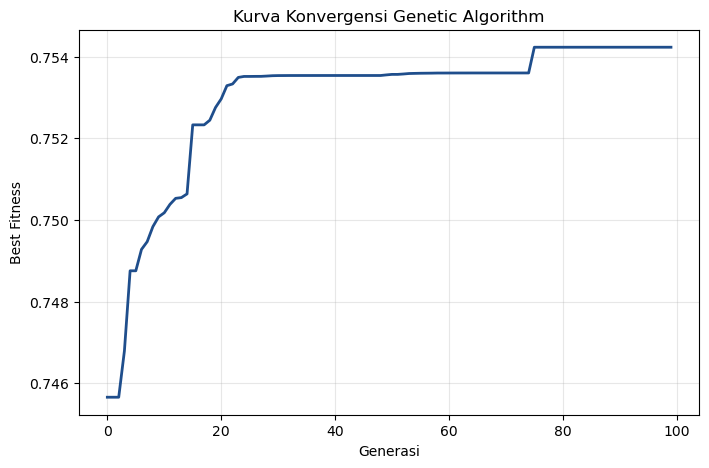

In [5]:
print("Memulai proses Genetic Algorithm (konfigurasi default)...")
best_weights, best_fit, history = run_genetic_algorithm()

print("\n--- HASIL OPTIMASI ---")
print(f"Best Fitness      : {best_fit:.6f}")
print(f"Korelasi Spearman : {2*best_fit - 1:.6f}")
print("\nBobot optimal yang ditemukan (jumlah = 1):")
for nama, val in zip(FEATURES, best_weights):
    print(f"  {nama:16s}: {val:.4f}")

# Terapkan bobot terbaik -> priority_score (urutan order paling berisiko terlambat)
df_out = df[["order_id", "delivery_time"]].copy()
df_out["priority_score"] = S @ best_weights
print("\n5 order dengan prioritas (risiko keterlambatan) tertinggi:")
display(df_out.sort_values("priority_score", ascending=False).head())

# Plot konvergensi
plt.figure(figsize=(8, 5))
plt.plot(history, color="#1f4e8c", linewidth=2)
plt.title("Kurva Konvergensi Genetic Algorithm")
plt.xlabel("Generasi")
plt.ylabel("Best Fitness")
plt.grid(True, alpha=0.3)
plt.show()

## 5. Uji Parameter (Hyperparameter Tuning)
Membandingkan kinerja GA pada beberapa kombinasi ukuran populasi dan probabilitas mutasi.
Kurva konvergensi tiap skenario diplot bersama untuk memudahkan analisis pada laporan.

Memulai Uji Parameter...

--- Menjalankan Skenario 1 (Default) ---
Generasi 1/80 | Best Fitness: 0.745661
Generasi 10/80 | Best Fitness: 0.750074
Generasi 20/80 | Best Fitness: 0.752752
Generasi 30/80 | Best Fitness: 0.753530
Generasi 40/80 | Best Fitness: 0.753535
Generasi 50/80 | Best Fitness: 0.753550
Generasi 60/80 | Best Fitness: 0.753596
Generasi 70/80 | Best Fitness: 0.753597
Generasi 80/80 | Best Fitness: 0.754227
--- Menjalankan Skenario 2 (Populasi Kecil) ---
Generasi 1/80 | Best Fitness: 0.734070
Generasi 10/80 | Best Fitness: 0.747805
Generasi 20/80 | Best Fitness: 0.749121
Generasi 30/80 | Best Fitness: 0.750094
Generasi 40/80 | Best Fitness: 0.750391
Generasi 50/80 | Best Fitness: 0.751752
Generasi 60/80 | Best Fitness: 0.751923
Generasi 70/80 | Best Fitness: 0.751923
Generasi 80/80 | Best Fitness: 0.752047
--- Menjalankan Skenario 3 (Populasi Besar) ---
Generasi 1/80 | Best Fitness: 0.737221
Generasi 10/80 | Best Fitness: 0.752975
Generasi 20/80 | Best Fitness: 0.753509


,Skenario,Pop Size,Crossover Rate,Mutation Rate,Best Fitness,Spearman
0,Skenario 1 (Default),50,0.8,0.1,0.754227,0.508455
1,Skenario 2 (Populasi Kecil),20,0.8,0.1,0.752047,0.504094
2,Skenario 3 (Populasi Besar),100,0.8,0.1,0.754229,0.508458
3,Skenario 4 (Mutasi Tinggi),50,0.8,0.5,0.754441,0.508882
4,Skenario 5 (Tanpa Mutasi),50,0.8,0.0,0.745890,0.491779


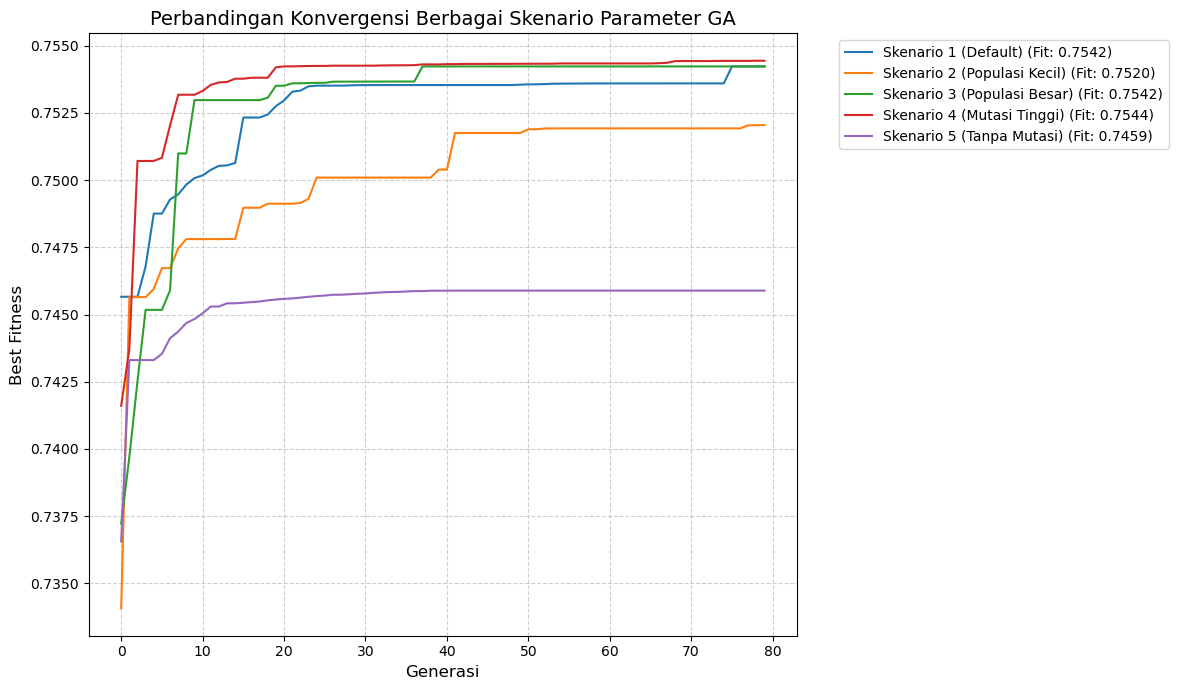

In [6]:
scenarios = [
    {"name": "Skenario 1 (Default)",       "pop_size": 50,  "p_c": 0.8, "p_m": 0.1, "gen": 80},
    {"name": "Skenario 2 (Populasi Kecil)","pop_size": 20,  "p_c": 0.8, "p_m": 0.1, "gen": 80},
    {"name": "Skenario 3 (Populasi Besar)","pop_size": 100, "p_c": 0.8, "p_m": 0.1, "gen": 80},
    {"name": "Skenario 4 (Mutasi Tinggi)", "pop_size": 50,  "p_c": 0.8, "p_m": 0.5, "gen": 80},
    {"name": "Skenario 5 (Tanpa Mutasi)",  "pop_size": 50,  "p_c": 0.8, "p_m": 0.0, "gen": 80},
]

plt.figure(figsize=(12, 7))
results = []
print("Memulai Uji Parameter...\n")
for sc in scenarios:
    print(f"--- Menjalankan {sc['name']} ---")
    globals()['POP_SIZE'] = sc['pop_size']
    globals()['P_C'] = sc['p_c']
    globals()['P_M'] = sc['p_m']
    globals()['MAX_GEN'] = sc['gen']

    _, bf, hist = run_genetic_algorithm()
    results.append({
        "Skenario": sc['name'], "Pop Size": sc['pop_size'],
        "Crossover Rate": sc['p_c'], "Mutation Rate": sc['p_m'],
        "Best Fitness": round(bf, 6), "Spearman": round(2*bf - 1, 6),
    })
    plt.plot(hist, label=f"{sc['name']} (Fit: {bf:.4f})")

# Kembalikan parameter ke default
globals()['POP_SIZE'] = 50
globals()['P_C'] = 0.8
globals()['P_M'] = 0.1
globals()['MAX_GEN'] = 100

print("\n--- RINGKASAN HASIL UJI PARAMETER ---")
display(pd.DataFrame(results))

plt.title("Perbandingan Konvergensi Berbagai Skenario Parameter GA", fontsize=14)
plt.xlabel("Generasi", fontsize=12)
plt.ylabel("Best Fitness", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 6. Kesimpulan

Berdasarkan hasil eksekusi Genetic Algorithm dan *hyperparameter tuning* di atas, dapat ditarik beberapa
kesimpulan terkait **optimasi bobot skor prioritas pengiriman**:

1. **Keberhasilan Algoritma**: GA berhasil menaikkan nilai *fitness* = (Spearman + 1) / 2 dari generasi ke
   generasi, lalu konvergen. Artinya bobot yang ditemukan membuat *priority_score* semakin selaras dengan
   pola `delivery_time` historis, dan **mengungguli baseline equal-weight** (Spearman 0,4295 / fitness 0,7148).
2. **Dampak Ukuran Populasi**: populasi lebih besar (Skenario 3) menghasilkan keberagaman solusi lebih tinggi
   sehingga fitness akhir cenderung lebih baik, namun beban komputasi meningkat. Populasi kecil (Skenario 2)
   lebih cepat tetapi rentan konvergensi prematur.
3. **Dampak Tingkat Mutasi**: tanpa mutasi (Skenario 5) peningkatan fitness berhenti lebih awal karena variasi
   populasi habis; mutasi terlalu tinggi (Skenario 4) membuat pencarian kurang stabil. Mutasi sedang (Skenario 1)
   menyeimbangkan eksplorasi dan eksploitasi.

*Bobot optimal yang dihasilkan dapat digunakan untuk membentuk skor prioritas pengiriman sehingga order dengan
potensi keterlambatan tinggi dapat diidentifikasi lebih awal sebagai dasar Decision Support System.*